# Probability of Default (PD) Model Development

### Objective

Develop an interpretable Probability of Default (PD) model using Logistic Regression on the final WOE-transformed feature set.

The model aims to estimate the likelihood of borrower default and serve as the foundation for credit scorecard development.

### Modeling Framework

* Logistic Regression
* WOE-transformed predictors
* Binary target (60+ DPD Event)
* Train/Test validation
* Regulatory-style scorecard methodology

### Evaluation Metrics

* ROC-AUC
* KS Statistic
* Gini Coefficient
* Confusion Matrix
* Score Distribution Analysis

### Final Predictor Set

* avg_instalment_remaining
* num_approved
* num_prev_apps
* age_years
* avg_credit_grant_ratio
* num_refused
* max_dpd_l12m
* avg_credit_age_years


In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
train_model = pd.read_csv(
    "../Dataset/processed/train_model.csv"
)

test_model = pd.read_csv(
    "../Dataset/processed/test_model.csv"
)

train_model.shape, test_model.shape

((204150, 8), (87493, 8))

In [3]:
X_train = train_model.drop(
    columns=['TARGET']
)

y_train = train_model['TARGET']

X_test = test_model.drop(
    columns=['TARGET']
)

y_test = test_model['TARGET']

In [4]:
X_train_sm = sm.add_constant(X_train)

logit_model = sm.Logit(
    y_train,
    X_train_sm
)

result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.125694
         Iterations 9


In [5]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:               204150
Model:                          Logit   Df Residuals:                   204142
Method:                           MLE   Df Model:                            7
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                 0.06933
Time:                        21:34:55   Log-Likelihood:                -25660.
converged:                       True   LL-Null:                       -27572.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -3.4838      0.014   -248.034      0.000      -3.511      -3.456
avg_instalment_remaining_woe     1.2674      0.023     54.581      0.000     

In [6]:
coef_df = pd.DataFrame({

    'variable': result.params.index,

    'coefficient': result.params.values,

    'pvalue': result.pvalues.values

})

coef_df.sort_values(
    'pvalue'
)

,variable,coefficient,pvalue
0,const,-3.483838,0.000000e+00
1,avg_instalment_remaining_woe,1.267431,0.000000e+00
2,num_approved_woe,1.249405,6.082357e-79
6,num_refused_woe,0.758604,7.370257e-33
4,age_years_woe,0.883654,1.191469e-32
5,avg_credit_grant_ratio_woe,0.385205,1.762178e-15
7,avg_credit_age_years_woe,0.346627,2.203214e-04
3,num_prev_apps_woe,-0.051651,5.152294e-01


In [7]:
significant_vars = coef_df[
    (coef_df['pvalue'] < 0.05)
    &
    (coef_df['variable'] != 'const')
]['variable'].tolist()

In [8]:
X_train_final = sm.add_constant(
    X_train[significant_vars]
)

final_model = sm.Logit(
    y_train,
    X_train_final
).fit()

print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.125695
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:               204150
Model:                          Logit   Df Residuals:                   204143
Method:                           MLE   Df Model:                            6
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                 0.06932
Time:                        21:35:06   Log-Likelihood:                -25661.
converged:                       True   LL-Null:                       -27572.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -3.4838      0.014   -248.026      0.000

In [9]:
train_pred = final_model.predict(
    X_train_final
)

In [10]:
X_test_final = sm.add_constant(
    X_test[significant_vars]
)

test_pred = final_model.predict(
    X_test_final
)

### ROC AUC

In [11]:
train_auc = roc_auc_score(
    y_train,
    train_pred
)

test_auc = roc_auc_score(
    y_test,
    test_pred
)

print(train_auc)
print(test_auc)

0.7141226854335342
0.703362628324


### GINI

In [12]:
train_gini = 2*train_auc - 1

test_gini = 2*test_auc - 1

print(train_gini)
print(test_gini)

0.4282453708670684
0.40672525664799997


### KS 

In [13]:
from scipy.stats import ks_2samp

ks = ks_2samp(
    test_pred[y_test==1],
    test_pred[y_test==0]
)

print(
    f"KS = {ks.statistic:.4f}"
)

KS = 0.2907


### ROC Curve

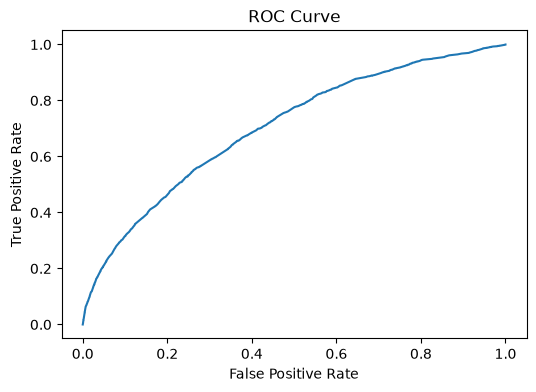

In [14]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_pred
)

plt.figure(figsize=(6,4))

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [15]:
test_scored = test_model.copy()

test_scored['PD'] = test_pred

In [16]:
test_scored.head()

,avg_instalment_remaining_woe,num_approved_woe,num_prev_apps_woe,age_years_woe,avg_credit_grant_ratio_woe,num_refused_woe,avg_credit_age_years_woe,TARGET,PD
0,-0.235912,0.375540,0.230856,0.104874,0.532725,0.334957,0.001118,0,0.058497
1,-0.235912,0.111282,-0.035567,-0.043450,-0.094022,-0.183214,0.001118,0,0.020679
2,-0.235912,0.375540,0.230856,-0.043450,-0.094022,-0.183214,0.001118,0,0.028291
3,0.257366,0.111282,0.230856,0.104874,-0.094022,-0.183214,0.135469,0,0.045000
4,-0.635485,0.111282,0.230856,0.104874,-0.319719,0.219054,0.001118,0,0.017605


In [17]:
test_scored['risk_band'] = pd.qcut(

    test_scored['PD'],

    q=10,

    labels=[
        '1','2','3','4','5',
        '6','7','8','9','10'
    ]
)

band_summary = (
    test_scored
    .groupby('risk_band')
    ['TARGET']
    .mean()
)

band_summary

risk_band
1     0.009593
2     0.008271
3     0.014480
4     0.014891
5     0.023400
6     0.026821
7     0.029930
8     0.038402
9     0.045738
10    0.091200
Name: TARGET, dtype: float64

In [18]:
coef_df.to_csv(
    "../Reports/model_coefficients.csv",
    index=False
)

test_scored.to_csv(
    "../Dataset/processed/test_scored.csv",
    index=False
)

### Risk Band Validation

Applicants were segmented into ten risk bands based on predicted Probability of Default (PD).

The observed bad rate increased consistently across risk bands, demonstrating effective rank ordering and discriminatory power.

| Lowest Risk Band | Highest Risk Band |
|------------------|------------------|
| 0.96% Bad Rate | 9.12% Bad Rate |

The highest-risk segment exhibited approximately 9.5 times the default rate of the lowest-risk segment, indicating strong separation between low-risk and high-risk borrowers.

The monotonic increase in bad rates across deciles confirms that the model successfully ranks applicants according to their relative credit risk.

### Saving Model Artifacts

In [19]:
import pickle

with open(
    "../Models/final_logit.pkl",
    "wb"
) as f:

    pickle.dump(
        final_model,
        f
    )

In [20]:
print(significant_vars)

['avg_instalment_remaining_woe', 'num_approved_woe', 'age_years_woe', 'avg_credit_grant_ratio_woe', 'num_refused_woe', 'avg_credit_age_years_woe']


In [21]:
X_train_sm = sm.add_constant(
    X_train[significant_vars]
)

final_model = sm.Logit(
    y_train,
    X_train_sm
).fit()

Optimization terminated successfully.
         Current function value: 0.125695
         Iterations 9


In [22]:
final_features = [
    'avg_instalment_remaining_woe',
    'num_approved_woe',
    'age_years_woe',
    'avg_credit_grant_ratio_woe',
    'num_refused_woe',
    'avg_credit_age_years_woe'
]

import pickle

with open(
    "../Models/final_features.pkl",
    "wb"
) as f:
    
    pickle.dump(
        final_features,
        f
    )

In [23]:
model_performance = pd.DataFrame({
    "Metric": ["AUC_Train","AUC_Test","Gini_Train","Gini_Test","KS"],
    "Value": [
        train_auc,
        test_auc,
        train_gini,
        test_gini,
        ks.statistic
    ]
})

model_performance.to_csv(
    "../Reports/model_performance.csv",
    index=False
)

In [24]:
final_features = [
    'avg_instalment_remaining_woe',
    'num_approved_woe',
    'age_years_woe',
    'avg_credit_grant_ratio_woe',
    'num_refused_woe',
    'avg_credit_age_years_woe'
]

pd.DataFrame({
    "feature": final_features
}).to_csv(
    "../Reports/final_features.csv",
    index=False
)